In [ ]:
# Import Libraries

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull

from concurrent.futures import ThreadPoolExecutor
from sklearn.metrics import accuracy_score, classification_report, silhouette_score, silhouette_samples
from matplotlib.cm import viridis


In [ ]:
# Define Inputs
INPUT_DIR = r"C:\Users\WilsonSIRL5-MCY-E113\Documents\White glacier ML\tif in total"
GLACIER_OUTLINE_PATH = r"C:\Users\WilsonSIRL5-MCY-E113\Documents\White glacier ML\White outline\glims_polygons.shp"
CLASSIFIER_SAVE_PATH = r"C:\Users\WilsonSIRL5-MCY-E113\Documents\White glacier ML\rf_classifier.joblib"
CLASSIFY_IMAGE_FILE = "Sentinel2_2021-08-06.tif"
n_clusters = 4
SAMPLE_SIZE_PER_LABEL = 100000
PCA_N_COMPONENTS = 2

In [3]:
# Set Environment Variables and Device
os.environ['LOKY_MAX_CPU_COUNT'] = '4'  # Suppress warning
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load Image Files
image_files = glob.glob(os.path.join(INPUT_DIR, "*.tif"))

In [4]:
# Parallel Image Processing Function
def process_image(img_path):
    """Read and process a single TIFF image."""
    with rasterio.open(img_path) as img:
        r = torch.tensor(img.read(1), dtype=torch.float16).to(device)
        g = torch.tensor(img.read(2), dtype=torch.float16).to(device)
        b = torch.tensor(img.read(3), dtype=torch.float16).to(device)
        ir = torch.tensor(img.read(4), dtype=torch.float16).to(device)
    stacked = torch.stack((r, g, b, ir), dim=-1).view(-1, 4)
    return stacked

# Silhouette Score Calculation
def calculate_silhouette_score(data, labels):
    """Calculate silhouette score for clustering quality."""
    return silhouette_score(data, labels)

# Image Classification Function
def classify_image(image_path, model, pca_transformer):
    """Classify a new image using the trained model."""
    with rasterio.open(image_path) as img:
        r = img.read(1)
        g = img.read(2)
        b = img.read(3)
        ir = img.read(4)
    stacked = np.dstack((r, g, b, ir)).reshape((-1, 4))
    stacked_pca = pca_transformer.transform(stacked)
    predicted_labels = model.predict(stacked_pca)
    return predicted_labels.reshape(img.height, img.width)

# Silhouette Score Calculation
def calculate_silhouette_score(data, labels):
    """Calculate silhouette score for clustering quality."""
    return silhouette_score(data, labels)

def plot_silhouette_analysis(ax, silhouette_values, labels, n_clusters):
    """Plot silhouette analysis for clustering evaluation."""
    ax.set_title("Silhouette Plot for Clusters")
    ax.set_xlabel("Silhouette Coefficient Values")
    ax.set_ylabel("Cluster Label")
    
    y_lower = 10
    for cluster_id in range(n_clusters):
        cluster_silhouette_values = silhouette_values[labels == cluster_id]
        cluster_silhouette_values.sort()
        size_cluster = cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster
        color = viridis(float(cluster_id) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id))
        y_lower = y_upper + 10
    ax.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Avg silhouette: {silhouette_avg:.2f}")
    ax.set_yticks([])
    ax.set_xticks(np.arange(-0.1, 1.1, 0.2))
    ax.legend(loc='upper right')

def plot_clusters_with_convex_hull(data, labels, centers, n_clusters, ax):
    """Plot 2D scatter with clustering results and convex hulls."""
    colors = viridis(np.linspace(0, 1, n_clusters))
    for cluster_id in range(n_clusters):
        cluster_points = data[labels == cluster_id]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster_id}",
                   alpha=0.6, s=50, color=colors[cluster_id])
        if len(cluster_points) >= 3:
            hull = ConvexHull(cluster_points)
            for simplex in hull.simplices:
                ax.plot(cluster_points[simplex, 0], cluster_points[simplex, 1],
                        color=colors[cluster_id], linewidth=1.5)
    ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker='X', label='Centers')
    ax.set_title("2D PCA Components with Clusters")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    ax.legend(loc='lower left')
    ax.grid(True)

In [5]:
# Load and Process All Images
all_data = []
with ThreadPoolExecutor() as executor:
    results = executor.map(process_image, image_files)
    all_data.extend(results)
all_data = torch.cat(all_data, dim=0)

# Dimensionality Reduction with PCA
all_data_np = all_data.cpu().numpy()  # Move to CPU for PCA
pca = PCA(n_components=PCA_N_COMPONENTS)
all_data_pca = pca.fit_transform(all_data_np)

# Print Explained Variance
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained_variance_ratio[0]*100:.2f}%")
print(f"Variance explained by PC2: {explained_variance_ratio[1]*100:.2f}%")
print(f"Total explained variance with 2 components: {explained_variance_ratio.sum()*100:.2f}%")

Variance explained by PC1: 99.65%
Variance explained by PC2: 0.31%
Total explained variance with 2 components: 99.96%


In [6]:
# K-means Clustering (Unsupervised Step)
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(all_data_pca)
unique, counts = np.unique(labels, return_counts=True)
print(f"Label counts: {dict(zip(unique, counts))}")

# Balanced Subsampling
resampled_data = []
resampled_labels = []
for label in np.unique(labels):
    label_data = all_data_pca[labels == label]
    resampled_data.append(resample(label_data, n_samples=SAMPLE_SIZE_PER_LABEL, random_state=42))
    resampled_labels.extend([label] * SAMPLE_SIZE_PER_LABEL)
all_data_sample = np.vstack(resampled_data)
labels_sample = np.array(resampled_labels)
unique, counts = np.unique(labels_sample, return_counts=True)
print(f"Label counts after subsampling: {dict(zip(unique, counts))}")

with ThreadPoolExecutor() as executor:
    future = executor.submit(calculate_silhouette_score, all_data_sample, labels_sample)
    silhouette_avg = future.result()
print(f"Silhouette Score (sampled data): {silhouette_avg}")

# Silhouette Analysis and Clustering Visualization
sample_silhouette_values = silhouette_samples(all_data_sample, labels_sample)

Label counts: {0: 390127924, 1: 52892331, 2: 44652149, 3: 62910846}
Label counts after subsampling: {0: 10000, 1: 10000, 2: 10000, 3: 10000}
Silhouette Score (sampled data): 0.6062604169901828


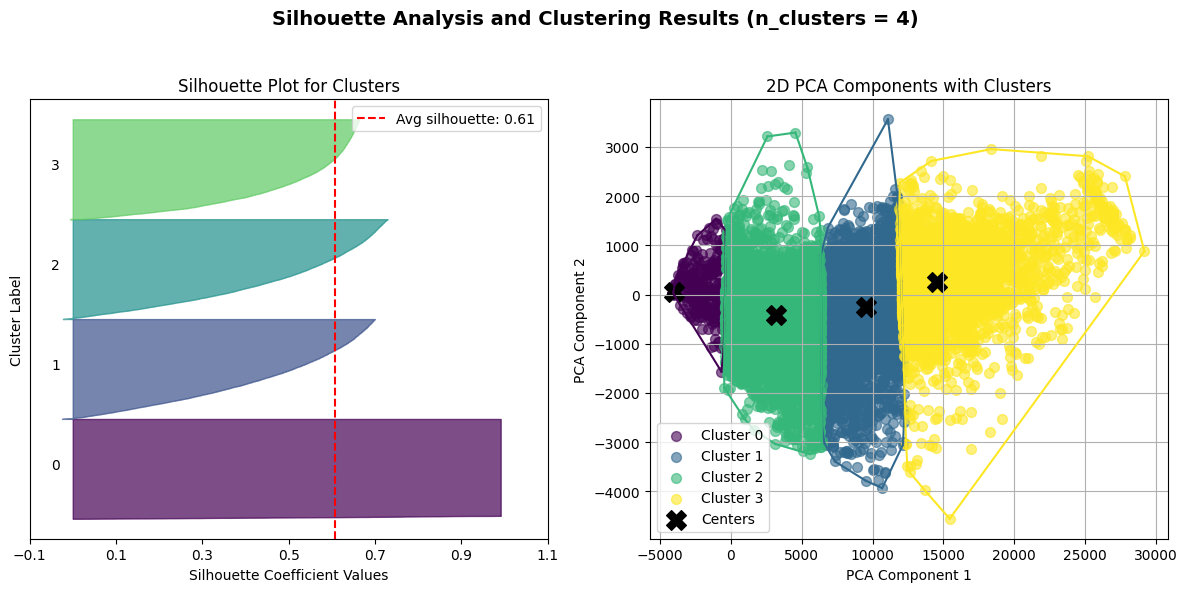

In [9]:
# Create and Display Silhouette and Cluster Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Silhouette Analysis and Clustering Results (n_clusters = 4)", fontsize=14, fontweight='bold')
plot_silhouette_analysis(ax1, sample_silhouette_values, labels_sample, n_clusters)
plot_clusters_with_convex_hull(all_data_sample, labels_sample, kmeans.cluster_centers_, n_clusters, ax2)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [10]:
# Train Random Forest Classifier
X_train, X_test, y_train, y_test = train_test_split(all_data_sample, labels_sample, test_size=0.3, random_state=42)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Evaluate the classifier
y_pred = rf_classifier.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

# Save the trained classifier
joblib.dump(rf_classifier, CLASSIFIER_SAVE_PATH)
print(f"Random Forest classifier saved to: {CLASSIFIER_SAVE_PATH}")

Accuracy: 0.9993333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3066
           1       1.00      1.00      1.00      2931
           2       1.00      1.00      1.00      2995
           3       1.00      1.00      1.00      3008

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000

Random Forest classifier saved to: C:\Users\WilsonSIRL5-MCY-E113\Documents\White glacier ML\rf_classifier.joblib


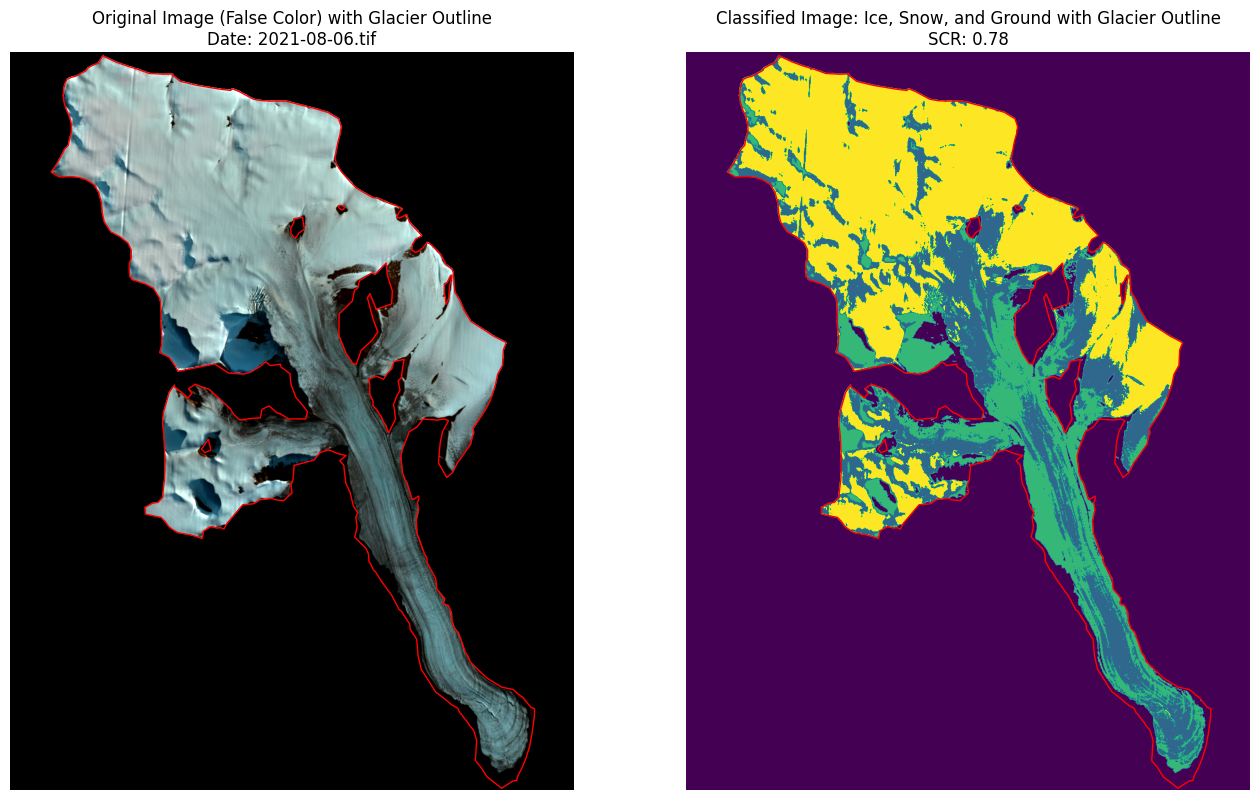

In [15]:
# Example Classification and Visualization
image_path = os.path.join(INPUT_DIR, CLASSIFY_IMAGE_FILE)
classified_image = classify_image(image_path, rf_classifier, pca)

# Calculate Areal Extent and Snow Cover Ratio (SCR)
unique, counts = np.unique(classified_image, return_counts=True)
pixel_counts = dict(zip(unique, counts))
ice_area = pixel_counts.get(2, 0)  # Assuming 2 is ice
snow_area = pixel_counts.get(1, 0) + pixel_counts.get(3, 0)  # Assuming 1 + 3 is snow
total_area = ice_area + snow_area
scr = snow_area / total_area if total_area != 0 else 0

# Load and Prepare Visualization Data
with rasterio.open(image_path) as src:
    band_1 = src.read(1)  # Blue
    band_2 = src.read(2)  # Green
    band_3 = src.read(3)  # Red
    band_4 = src.read(4)  # NIR
    sentinel_crs = src.crs
    sentinel_extent = src.bounds

# Create False Color Image
false_color = np.dstack((band_4, band_2, band_1))
false_color = (false_color - false_color.min()) / (false_color.max() - false_color.min()) * 255
false_color = false_color.astype(np.uint8)
mean = np.mean(false_color, axis=(0, 1), keepdims=True)
false_color = np.clip((false_color - mean) * 1.5 + mean, 0, 255).astype(np.uint8)

# Load Glacier Outline
glacier_outline = gpd.read_file(GLACIER_OUTLINE_PATH)
glacier_outline = glacier_outline.to_crs(sentinel_crs)

# Visualize Results
fig, axes = plt.subplots(1, 2, figsize=(16, 20))
extent = [sentinel_extent.left, sentinel_extent.right, sentinel_extent.bottom, sentinel_extent.top]

# Original Image with Glacier Outline
axes[0].imshow(false_color, extent=extent)
glacier_outline.plot(ax=axes[0], facecolor='none', edgecolor='r', zorder=2)
axes[0].set_title(f'Original Image (False Color) with Glacier Outline\nDate: {CLASSIFY_IMAGE_FILE.split("_")[1].split("(")[0]}')
axes[0].axis('off')

# Classified Image with Glacier Outline
axes[1].imshow(classified_image, cmap='viridis', extent=extent)
glacier_outline.plot(ax=axes[1], facecolor='none', edgecolor='r', zorder=2)
axes[1].set_title(f'Classified Image: Ice, Snow, and Ground with Glacier Outline\nSCR: {scr:.2f}')
axes[1].axis('off')

plt.show()